In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense , Input , Flatten , Dropout , BatchNormalization , LSTM

In [12]:
df1 = pd.read_csv("/content/Kolkata 2018-01-01 to 2019-12-31.csv")
df1 = df1[['datetime' , 'temp',	'humidity',	'dew',	'cloudcover',	'windspeed'	,'sealevelpressure','solarradiation' , 'uvindex']]

df2 = pd.read_csv("/content/Kolkata, WB, IN 2020-01-01 to 2021-12-31.csv")
df2 = df2[['datetime' , 'temp',	'humidity',	'dew',	'cloudcover',	'windspeed'	,'sealevelpressure','solarradiation' , 'uvindex']]

df3 = pd.read_csv("/content/Kolkata, WB, IN 2022-01-01 to 2023-12-31.csv")
df3 = df3[['datetime' , 'temp',	'humidity',	'dew',	'cloudcover',	'windspeed'	,'sealevelpressure','solarradiation' , 'uvindex']]

df4 = pd.read_csv("/content/kolkata 2024-01-01 to 2025-12-14.csv")
df4 = df4[['datetime' , 'temp',	'humidity',	'dew',	'cloudcover',	'windspeed'	,'sealevelpressure','solarradiation' , 'uvindex']]

df5 = pd.read_csv("/content/Kolkata 2016-01-01 to 2017-12-31.csv")
df5 = df5[['datetime' , 'temp',	'humidity',	'dew',	'cloudcover',	'windspeed'	,'sealevelpressure','solarradiation' , 'uvindex']]


In [13]:
import re
from dateutil import parser

def to_yyyy_mm_dd(date_str):
    """
    Convert a date string of any common order (D/M/Y, M/D/Y, Y/M/D)
    into YYYY-MM-DD format.
    If already in YYYY-MM-DD, return as-is.
    """

    # Check if already in YYYY-MM-DD format
    if re.fullmatch(r"\d{4}-\d{2}-\d{2}", date_str):
        return date_str

    # Otherwise parse and convert
    dt = parser.parse(date_str, dayfirst=True)
    return dt.strftime("%Y-%m-%d")


In [14]:
to_yyyy_mm_dd('2018-01-02')

'2018-01-02'

In [15]:
df = pd.concat([df5 , df1,df2,df3,df4])

df.reset_index(drop = True , inplace = True)

df['datetime'] = df['datetime'].apply(lambda x : to_yyyy_mm_dd(x) )
df['datetime'] = pd.to_datetime(df['datetime'])
df['month'] = df['datetime'].dt.month
df['day_no'] = df['datetime'].dt.day

df.drop(columns = ['datetime'] , inplace = True)

df.head()

,temp,humidity,dew,cloudcover,windspeed,sealevelpressure,solarradiation,uvindex,month,day_no
0,66.6,77.8,58.2,1.9,4.7,1018.6,187.9,7,1,1
1,67.7,77.6,59.4,7.5,4.7,1017.6,188.6,7,1,2
2,67.7,81.1,61.1,13.7,5.8,1016.5,156.3,6,1,3
3,67.2,76.1,58.4,7.6,5.8,1017.3,187.4,7,1,4
4,66.1,78.9,58.5,0.0,3.4,1016.0,190.3,7,1,5


In [16]:
df['humidity'] = df['humidity'] / 100.0
df['cloudcover'] = df['cloudcover'] / 100.0
df['uvindex'] = df['uvindex'] / 11.0

In [17]:
# month (1–12)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# day of year (1–365)
df['day_sin'] = np.sin(2 * np.pi * df['day_no'] / 31)
df['day_cos'] = np.cos(2 * np.pi * df['day_no'] / 31)

df = df.drop(columns=['month', 'day_no'])


In [18]:
x = df.drop(columns=['temp'])
y = df['temp']

In [19]:
test_fraction = 0.2

In [20]:
x.shape

(3636, 11)

In [21]:
total_size = x.shape[0]
training_size = np.floor(total_size * (1 - test_fraction)).astype(int)
training_size

np.int64(2908)

In [22]:
x_train = x.iloc[0 : training_size]
x_test = x.iloc[training_size:]

y_train = y.iloc[0 : training_size]
y_test = y.iloc[training_size:]

In [23]:
y_scaler = StandardScaler()
x_scaler = StandardScaler()

x_train.loc[:, ['dew', 'windspeed', 'sealevelpressure', 'solarradiation']] = x_scaler.fit_transform(x_train[['dew', 'windspeed', 'sealevelpressure', 'solarradiation']])
y_train = y_scaler.fit_transform(y_train.values.reshape(-1, 1))

x_test.loc[:, ['dew', 'windspeed', 'sealevelpressure', 'solarradiation']] = x_scaler.transform(x_test[['dew', 'windspeed', 'sealevelpressure', 'solarradiation']])
y_test = y_scaler.transform(y_test.values.reshape(-1, 1))


In [24]:
x_train = np.array(x_train)
x_test = np.array(x_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [25]:
day_size = 10
train_len = len(x_train)

x_train_sequence = []
y_train_sequence = []

for s in range(0 , train_len - day_size):
  temp = []
  for day in range(s , s + day_size ):
    temp.append(x_train[ day ])

  x_train_sequence.append(temp)
  y_train_sequence.append(y_train[s + day_size])

x_train_sequence = np.array(x_train_sequence)
y_train_sequence = np.array(y_train_sequence).flatten()

In [26]:
test_len = len(x_test)

x_test_sequence = []
y_test_sequence = []

for s in range(0 , test_len - day_size):
  temp = []
  for day in range(s , s + day_size ):
    temp.append(x_test[ day ])

  x_test_sequence.append(temp)
  y_test_sequence.append(y_test[s + day_size])

x_test_sequence = np.array(x_test_sequence)
y_test_sequence = np.array(y_test_sequence).flatten()

In [27]:
((y_scaler.inverse_transform(y_train)-32)*(5/9)).max()

np.float64(34.833333333333336)

In [67]:
model = Sequential()

model.add(Input(shape = (len(x_train_sequence[0]) , len(x_train_sequence[0][0]) , )))

model.add(LSTM(5 , return_sequences= False , dropout=0 ))

# model.add(LSTM(7 , return_sequences= True ))

# model.add(LSTM(5))

# model.add(Dense(5 , activation = 'tanh'))

# model.add(Dense(10 , activation = 'tanh'))

model.add(Dense(1 , activation = 'linear'))

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 5)              │           340 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 346 (1.35 KB)

 Trainable params: 346 (1.35 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
model.compile(loss = 'mean_squared_error' , optimizer = tf.keras.optimizers.Adam(learning_rate=0.001) , metrics = ['mse'])

In [69]:
history = model.fit(x_train_sequence , y_train_sequence , batch_size = 32, epochs = 50 , shuffle = False)

Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1.5210 - mse: 1.5210
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.9779 - mse: 0.9779
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6332 - mse: 0.6332
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4249 - mse: 0.4249
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3082 - mse: 0.3082
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2398 - mse: 0.2398
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2021 - mse: 0.2021
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1752 - mse: 0.1752
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1545 - mse: 0.1545
Epoch 10/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1398 - mse: 0.1398
Epoch 11/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1298 - mse: 0.1298
Epoch 12/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1229 - mse: 0.1229
Epoch 13/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/ste

In [70]:
y_pred_scaled = model.predict(x_train_sequence)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


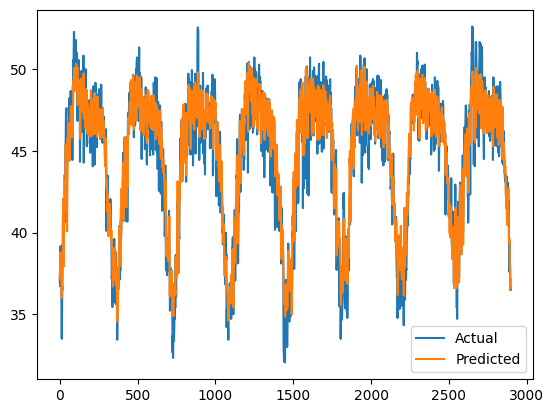

In [71]:
plt.plot(y_scaler.inverse_transform(y_train_sequence.reshape(-1, 1))*(5/9) , label = 'Actual')
plt.plot(y_pred*(5/9) , label = 'Predicted')
plt.legend()

In [72]:
af = y_scaler.inverse_transform( y_train_sequence.reshape(-1, 1) )
bf = y_pred

ac = (af-32)*(5/9)
bc = (bf-32)*(5/9)

print(r2_score(ac , bc))
print(np.sqrt(mean_squared_error(ac , bc)))

0.9169307841993732
1.243370165074248


In [73]:
y_pred_scaled = model.predict(x_test_sequence)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


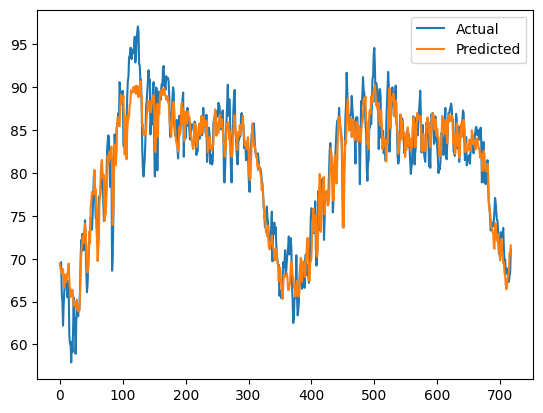

In [74]:
plt.plot(y_scaler.inverse_transform(y_test_sequence.reshape(-1, 1)) , label = 'Actual')
plt.plot(y_pred , label = 'Predicted')
plt.legend()

In [75]:
af = y_scaler.inverse_transform(y_test_sequence.reshape(-1, 1))
bf = y_pred

ac = (af-32)*(5/9)
bc = (bf-32)*(5/9)

print(r2_score(ac , bc))
print(np.sqrt(mean_squared_error(ac , bc)))

0.8970640918990923
1.3743343613145051
